In [3]:
!pip install click


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
!python -m spacy download uk_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 640.6 kB/s  0:00:230:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 411.6 kB/s  0:00:32 eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 452.4 kB/s  0:00:17 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [uk-core-news-sm]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('uk_core_news_sm')


In [5]:
import spacy
import pandas as pd
from spacy import displacy

nlp = spacy.load("uk_core_news_sm")
print("Модель успішно завантажена")
print("Компоненти pipeline:", nlp.pipe_names)

Модель успішно завантажена
Компоненти pipeline: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [6]:
text = """
У серпні 2026 року президент України відвідав Київ і зустрівся
з представниками Організації Об'єднаних Націй. Під час зустрічі
обговорювали допомогу Україні та розвиток співпраці зі Сполученими Штатами.
Також делегація відвідала Одесу та Львів. Компанія Microsoft повідомила,
що планує підтримувати українські освітні проєкти.
"""

print(text)


У серпні 2026 року президент України відвідав Київ і зустрівся
з представниками Організації Об'єднаних Націй. Під час зустрічі
обговорювали допомогу Україні та розвиток співпраці зі Сполученими Штатами.
Також делегація відвідала Одесу та Львів. Компанія Microsoft повідомила,
що планує підтримувати українські освітні проєкти.



In [7]:
doc = nlp(text)
print("Кількість токенів:", len(doc))
print("Знайдено сутностей:", len(doc.ents))

Кількість токенів: 53
Знайдено сутностей: 8


In [8]:
for entity in doc.ents:
    print(
        f"Сутність: {entity.text:<35} "
        f"Мітка: {entity.label_:<10} "
        f"Пояснення: {spacy.explain(entity.label_)}"
    )

Сутність: України                             Мітка: LOC        Пояснення: Non-GPE locations, mountain ranges, bodies of water
Сутність: Київ                                Мітка: LOC        Пояснення: Non-GPE locations, mountain ranges, bodies of water
Сутність: Організації Об'єднаних Націй        Мітка: ORG        Пояснення: Companies, agencies, institutions, etc.
Сутність: Україні                             Мітка: LOC        Пояснення: Non-GPE locations, mountain ranges, bodies of water
Сутність: Сполученими Штатами                 Мітка: LOC        Пояснення: Non-GPE locations, mountain ranges, bodies of water
Сутність: Одесу                               Мітка: LOC        Пояснення: Non-GPE locations, mountain ranges, bodies of water
Сутність: Львів                               Мітка: LOC        Пояснення: Non-GPE locations, mountain ranges, bodies of water
Сутність: Microsoft                           Мітка: ORG        Пояснення: Companies, agencies, institutions, etc.


In [9]:
entities_data = []

for entity in doc.ents:
    entities_data.append({
        "Сутність": entity.text,
        "Мітка": entity.label_,
        "Пояснення": spacy.explain(entity.label_),
        "Початковий символ": entity.start_char,
        "Кінцевий символ": entity.end_char
    })

entities_df = pd.DataFrame(entities_data)
entities_df

,Сутність,Мітка,Пояснення,Початковий символ,Кінцевий символ
0,України,LOC,"Non-GPE locations, mountain ranges, bodies of ...",30,37
1,Київ,LOC,"Non-GPE locations, mountain ranges, bodies of ...",47,51
2,Організації Об'єднаних Націй,ORG,"Companies, agencies, institutions, etc.",81,109
3,Україні,LOC,"Non-GPE locations, mountain ranges, bodies of ...",150,157
4,Сполученими Штатами,LOC,"Non-GPE locations, mountain ranges, bodies of ...",183,202
5,Одесу,LOC,"Non-GPE locations, mountain ranges, bodies of ...",230,235
6,Львів,LOC,"Non-GPE locations, mountain ranges, bodies of ...",239,244
7,Microsoft,ORG,"Companies, agencies, institutions, etc.",255,264


In [10]:
entity_counts = (
    entities_df["Мітка"]
    .value_counts()
    .rename_axis("Тип сутності")
    .reset_index(name="Кількість")
)
entity_counts

,Тип сутності,Кількість
0,LOC,6
1,ORG,2


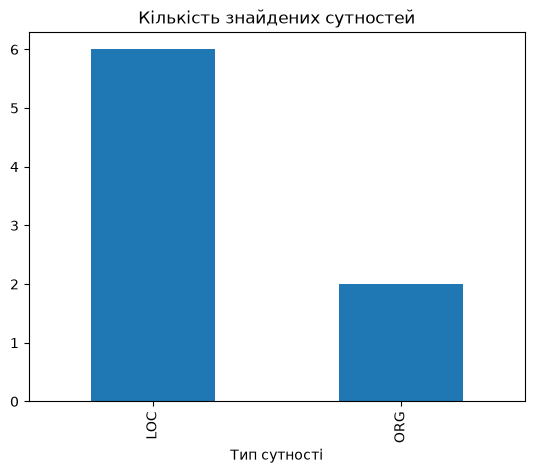

In [11]:
entity_counts.plot(
    kind="bar",
    x="Тип сутності",
    y="Кількість",
    legend=False,
    title="Кількість знайдених сутностей"
);

In [12]:
displacy.render(doc, style="ent", jupyter=True)

In [13]:
tokens_data = []

for token in doc:
    if not token.is_space:
        tokens_data.append({
            "Токен": token.text,
            "Лема": token.lemma_,
            "Частина мови": token.pos_,
            "Залежність": token.dep_,
            "Стоп-слово": token.is_stop
        })

tokens_df = pd.DataFrame(tokens_data)
tokens_df.head(20)

,Токен,Лема,Частина мови,Залежність,Стоп-слово
0,У,у,ADP,case,True
1,серпні,серпень,NOUN,obl,False
2,2026,2026,ADJ,amod,False
3,року,рок,NOUN,nmod,True
4,президент,президент,NOUN,nsubj,False
5,України,україна,PROPN,nmod,False
6,відвідав,відвідати,VERB,ROOT,False
7,Київ,київ,PROPN,obj,False
8,і,і,CCONJ,cc,True
9,зустрівся,зустрітися,VERB,conj,False


In [14]:
def find_entities(text_to_analyze):
    analyzed_doc = nlp(text_to_analyze)

    result = [
        {
            "Сутність": ent.text,
            "Мітка": ent.label_,
            "Пояснення": spacy.explain(ent.label_)
        }
        for ent in analyzed_doc.ents
    ]

    return pd.DataFrame(result)


my_text = (
    "Тарас Шевченко народився в Україні. "
    "Його твори зберігаються в музеях Києва."
)

find_entities(my_text)

,Сутність,Мітка,Пояснення
0,Тарас Шевченко,PER,Named person or family.
1,Україні,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
2,Києва,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
